In [16]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import xarray as xr
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import cartopy.feature as cfeature
import os
from sklearn.linear_model import LinearRegression
import xesmf as xe
from scipy.stats import gaussian_kde



In [2]:
home_path = os.path.expanduser("~")

path = '/DataFiles'
path2 = '/Library/Mobile Documents/com~apple~CloudDocs/Documents/Documents - MacBook Air/Python/Ice Cores/data/model/ccsm4_last_millenium'

racmo = xr.open_dataset(home_path + path + "/smb_monthlyS_ANT27_ERA5-3H_RACMO2.3p2_197901_202212.nc")
mask = xr.open_dataset(home_path + path + "/TotIS_RACMO_ANT27_IMBIE2.nc")

In [5]:
def compute_2d_bounds(arr):
    """
    Compute approximate 2D cell corner bounds for a 2D array.
    arr: 2D array of lat or lon with shape (ny, nx)
    Returns: 2D array of bounds with shape (ny+1, nx+1)
    """
    ny, nx = arr.shape

    # Compute interior points
    b = 0.5 * (arr[:-1, :-1] + arr[1:, 1:])

    # For edges, extend by copying first/last rows and columns
    b_full = np.zeros((ny+1, nx+1))
    # Fill interior
    b_full[1:-1, 1:-1] = 0.25*(arr[:-1, :-1] + arr[1:, :-1] + arr[:-1, 1:] + arr[1:, 1:])
    # Top/bottom edges
    b_full[0,1:-1] = arr[0,:-1] - 0.5*(arr[1,:-1]-arr[0,:-1])
    b_full[-1,1:-1] = arr[-1,:-1] + 0.5*(arr[-1,:-1]-arr[-2,:-1])
    # Left/right edges
    b_full[1:-1,0] = arr[:-1,0] - 0.5*(arr[:-1,1]-arr[:-1,0])
    b_full[1:-1,-1] = arr[:-1,-1] + 0.5*(arr[:-1,-1]-arr[:-1,-2])
    # Corners (copy nearest interior)
    b_full[0,0] = b_full[1,1]
    b_full[0,-1] = b_full[1,-2]
    b_full[-1,0] = b_full[-2,1]
    b_full[-1,-1] = b_full[-2,-2]

    return b_full

# Extract lat/lon from RACMO (2D DataArrays)
lat = racmo["lat"].values
lon = racmo["lon"].values

# Compute approximate 2D bounds
lat_b = compute_2d_bounds(lat)
lon_b = compute_2d_bounds(lon)

# Create new xarray Dataset for xESMF
grid_ds = xr.Dataset(
    {
        "lat": (["y", "x"], lat),
        "lon": (["y", "x"], lon),
        "lat_b": (["y_b", "x_b"], lat_b),
        "lon_b": (["y_b", "x_b"], lon_b),
    }
)

print(grid_ds)

cellArea = xe.util.cell_area(grid_ds, earth_radius=6371.0)  # km²
threshold = 800  # km²

cellArea_fixed = cellArea.copy()

# Loop over each latitude row
for i in range(cellArea_fixed.shape[0]):
    # Compute mean of cells below threshold for this row
    row_mean = cellArea_fixed[i, :].where(cellArea_fixed[i, :] <= threshold).mean()
    # Replace cells above threshold with row mean
    cellArea_fixed[i, :] = xr.where(cellArea_fixed[i, :] > threshold, row_mean, cellArea_fixed[i, :])

smb = racmo["smb"].squeeze("height")
smb_ann = smb.groupby("time.year").sum(dim="time").sel(year=slice(1979, 2022))


lat = racmo["lat"].values  # shape (rlat, rlon)
lon = racmo["lon"].values

cell_area_da = xr.DataArray(cellArea_fixed, dims=("rlat","rlon"))

smb_mass_ann = smb_ann * cell_area_da * 1000000

antarctic_smb_Gt_ann = smb_mass_ann.sum(dim=("rlat","rlon")) / 1e12




<xarray.Dataset> Size: 2MB
Dimensions:  (y: 240, x: 262, y_b: 241, x_b: 263)
Dimensions without coordinates: y, x, y_b, x_b
Data variables:
    lat      (y, x) float64 503kB -46.75 -46.92 -47.09 ... -47.42 -47.24 -47.07
    lon      (y, x) float64 503kB -126.9 -127.1 -127.3 ... 52.84 53.03 53.23
    lat_b    (y_b, x_b) float64 507kB -46.91 -46.67 -46.84 ... -47.17 -47.24
    lon_b    (y_b, x_b) float64 507kB -126.8 -127.0 -127.2 ... 52.69 52.89 53.28


In [ ]:
# --- 1️⃣ Annual SMB per grid cell ---
smb_ann = (
    racmo["smb"]
    .squeeze("height")
    .groupby("time.year")
    .sum(dim="time")
    .sel(year=slice(1979, 2022))
)

# --- 2️⃣ Define basin-based SMB totals (Gt/yr) ---
ais_smb  = smb_per_basin_Gt.sum(axis=1)
wais_smb = smb_per_basin_Gt[[3,7,8,9,10]].sum(axis=1)
eais_smb = smb_per_basin_Gt[[1,2,11,12,13,14,15,16,17,18]].sum(axis=1)
ap_smb   = smb_per_basin_Gt[[4,5,6]].sum(axis=1)

# --- 3️⃣ Normalize each series (anomaly in std units) ---
def normalize(series):
    return (series - series.mean()) / series.std()

ais_smb_anom  = normalize(ais_smb)
wais_smb_anom = normalize(wais_smb)
eais_smb_anom = normalize(eais_smb)
ap_smb_anom   = normalize(ap_smb)

# --- 4️⃣ Convert each to xarray DataArray for xarray compatibility ---
def to_xr(series, smb_ann):
    return xr.DataArray(
        series.values.astype(float),
        dims=["year"],
        coords={"year": smb_ann["year"].values}
    )

ais_smb_da  = to_xr(ais_smb_anom, smb_ann)
wais_smb_da = to_xr(wais_smb_anom, smb_ann)
eais_smb_da = to_xr(eais_smb_anom, smb_ann)
ap_smb_da   = to_xr(ap_smb_anom, smb_ann)

# --- 5️⃣ Robust correlation function ---
def corr_func(smb_ts, region_ts):
    smb_ts = np.asarray(smb_ts, dtype=float)
    region_ts = np.asarray(region_ts, dtype=float)
    mask = np.isfinite(smb_ts) & np.isfinite(region_ts)
    if mask.sum() < 2:
        return np.nan
    return np.corrcoef(smb_ts[mask], region_ts[mask])[0, 1]

# --- 6️⃣ Compute correlation maps for each region ---
def compute_corr_map(region_da):
    return xr.apply_ufunc(
        corr_func,
        smb_ann, region_da,
        input_core_dims=[["year"], ["year"]],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float]
    )

ais_corr_map  = compute_corr_map(ais_smb_da)
wais_corr_map = compute_corr_map(wais_smb_da)
eais_corr_map = compute_corr_map(eais_smb_da)
ap_corr_map   = compute_corr_map(ap_smb_da)


/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


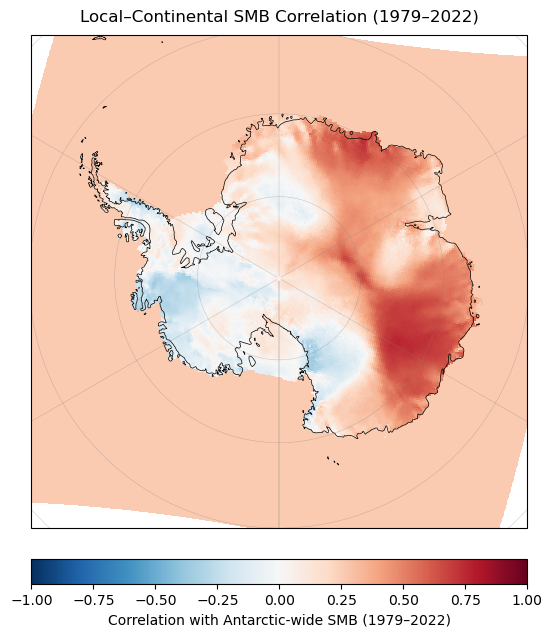

In [14]:
# Define projection
proj = ccrs.SouthPolarStereo()

# Create figure and axes
fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=proj)

# Set extent to include all Antarctica (lon from -180 to 180)
ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())

# Plot correlation map
im = ax.pcolormesh(
    racmo["lon"], racmo["lat"], eais_corr_map,
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r", vmin=-1, vmax=1
)

# Add colorbar
cb = plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.05, shrink=0.8)
cb.set_label("Correlation with Antarctic-wide SMB (1979–2022)")

# Add geographic features
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color="black")
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)

# Add gridlines
gl = ax.gridlines(draw_labels=False, linewidth=0.3, color="gray", alpha=0.5)
gl.xlocator = plt.FixedLocator(np.arange(-180, 181, 60))

# Add title
plt.title("Local–Continental SMB Correlation (1979–2022)", fontsize=12, pad=10)

plt.show()


In [ ]:
# Loading the ice core accumulation records
accumData = pd.read_csv(home_path + path + "/AccumCoresData.csv", header=None)
accumCores = accumData.iloc[2:, 1:][
    (accumData.iloc[2:, 0].astype(int) >= 1979) & (accumData.iloc[2:, 0].astype(int) <= 2000)
].to_numpy()[::-1]
accumCores = accumCores.astype(float)

# Assuming first row contains variable names, second row contains lat/lon
core_names = accumData.iloc[1, 1:].values
core_lats = accumData.iloc[0, 1:].astype(float).values
core_lons = accumData.iloc[1, 1:].astype(float).values
